In [2]:
import networkx as nx
import matplotlib.pyplot as plt
import io

# Path to the .mtx file
filepath = "ca-GrQc.mtx"

# Read the file and filter out header/comment lines
processed_lines = []
skip_dimension_line = True # Flag to skip the first non-comment line (dimensions)

with open(filepath, 'r') as f:
    for line in f:
        if line.startswith('%'):
            continue  # Skip comment lines

        if skip_dimension_line:
            skip_dimension_line = False # This is the dimension line, skip it
            continue

        processed_lines.append(line.strip())

# Create a file-like object from the processed lines
file_like_object = io.StringIO("\n".join(processed_lines))

# Load the graph using read_edgelist
G = nx.read_edgelist(file_like_object, nodetype=int)

print(f"Le réseau contient {G.number_of_nodes()} nœuds et {G.number_of_edges()} liens.")

Le réseau contient 4158 nœuds et 13422 liens.


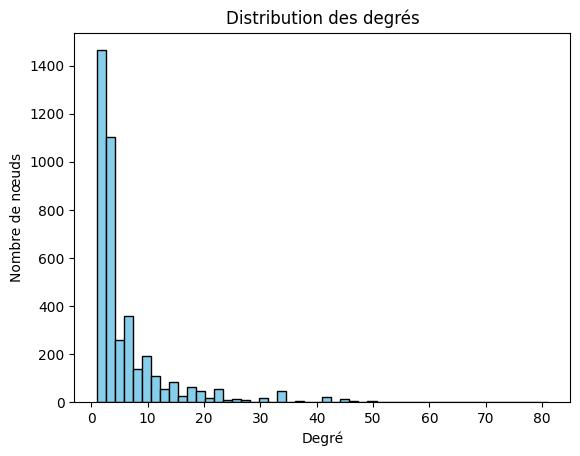

In [3]:
degrees = [d for n, d in G.degree()]
plt.hist(degrees, bins=50, color='skyblue', edgecolor='black')
plt.title("Distribution des degrés")
plt.xlabel("Degré")
plt.ylabel("Nombre de nœuds")
plt.show()

In [4]:
components = list(nx.connected_components(G))
print(f"Nombre de composants connectés : {len(components)}")
G_main = G.subgraph(max(components, key=len)) # On travaille sur le composant géant
print(f"Taille du composant géant : {len(G_main)} nœuds")

Nombre de composants connectés : 1
Taille du composant géant : 4158 nœuds


In [5]:
print(f"Diamètre (plus long chemin court) : {nx.diameter(G_main)}")
print(f"Chemin moyen court : {nx.average_shortest_path_length(G_main)}")

Diamètre (plus long chemin court) : 17
Chemin moyen court : 6.049380016182999


In [6]:
print(f"Densité du réseau : {nx.density(G)}")
print(f"Coefficient de clustering moyen : {nx.average_clustering(G)}")

Densité du réseau : 0.0015530402828935425
Coefficient de clustering moyen : 0.5568782161697929


In [9]:
!pip install cdlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.6/263.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 73.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 78.7 MB/s eta 0:00:00


In [7]:
deg_centrality = nx.degree_centrality(G)
# Trier pour trouver les 5 auteurs les plus centraux
top_authors = sorted(deg_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top 5 auteurs (Centralité de degré) :", top_authors)

Top 5 auteurs (Centralité de degré) : [(3348, 0.019485205677171036), (3388, 0.01900408948761126), (1924, 0.01852297329805148), (3614, 0.01852297329805148), (1065, 0.016357950445032476)]


In [10]:
from cdlib import algorithms, evaluation

# 1. Algorithme de Louvain
coms_louvain = algorithms.louvain(G)

# 2. Label Propagation
coms_lp = algorithms.label_propagation(G)

# 3. Infomap
coms_infomap = algorithms.infomap(G)

# Comparaison simple
print(f"Louvain : {len(coms_louvain.communities)} communautés trouvées")
print(f"Label Prop : {len(coms_lp.communities)} communautés trouvées")
print(f"Infomap : {len(coms_infomap.communities)} communautés trouvées")

# Évaluation (Modularité) : Plus elle est proche de 1, mieux c'est.
mod_louvain = evaluation.newman_girvan_modularity(G, coms_louvain)
print(f"Modularité Louvain : {mod_louvain.score}")

Note: to be able to use all crisp methods, you need to install some additional packages:  {'graph_tool', 'leidenalg', 'infomap', 'bayanpy'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'leidenalg', 'infomap'}
Louvain : 41 communautés trouvées
Label Prop : 629 communautés trouvées
Infomap : 317 communautés trouvées
Modularité Louvain : 0.8464125556555391


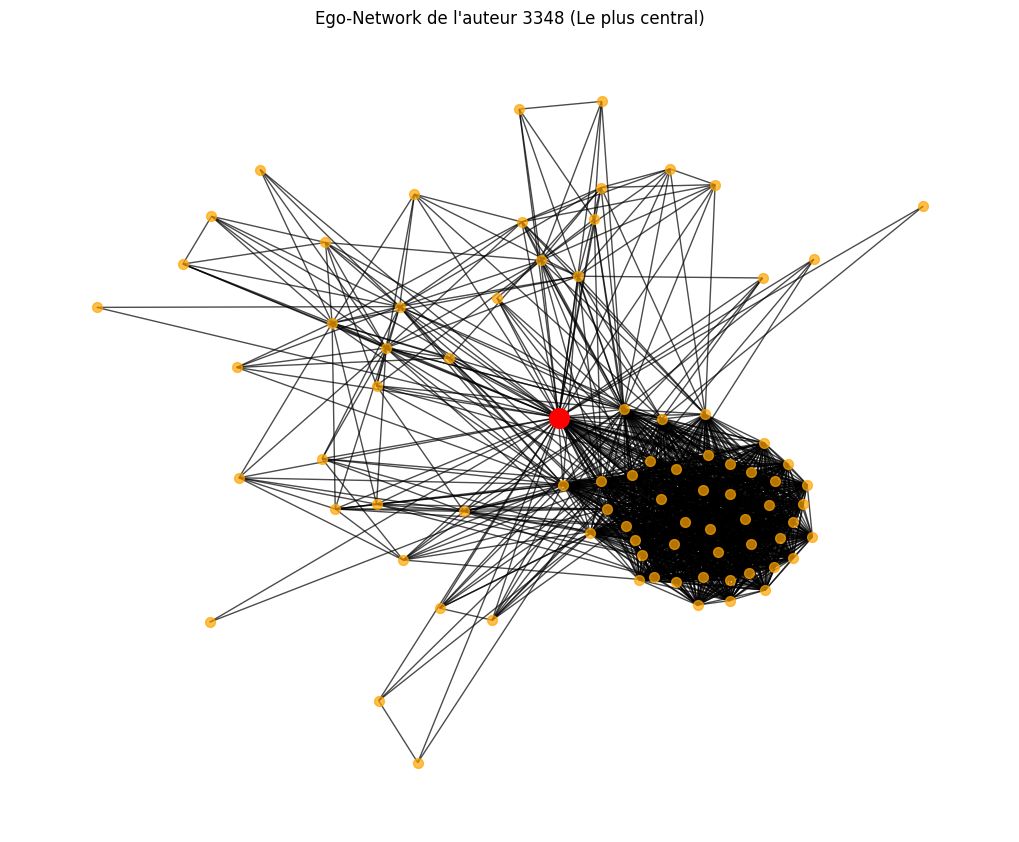

In [11]:
# On prend le nœud le plus central (ID 3348) et ses voisins directs
hub_node = 3348
ego_graph = nx.ego_graph(G, hub_node)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(ego_graph)
nx.draw(ego_graph, pos, node_size=50, node_color='orange', with_labels=False, alpha=0.7)
nx.draw_networkx_nodes(ego_graph, pos, nodelist=[hub_node], node_size=200, node_color='red') # Le Hub en rouge
plt.title(f"Ego-Network de l'auteur {hub_node} (Le plus central)")
plt.show()

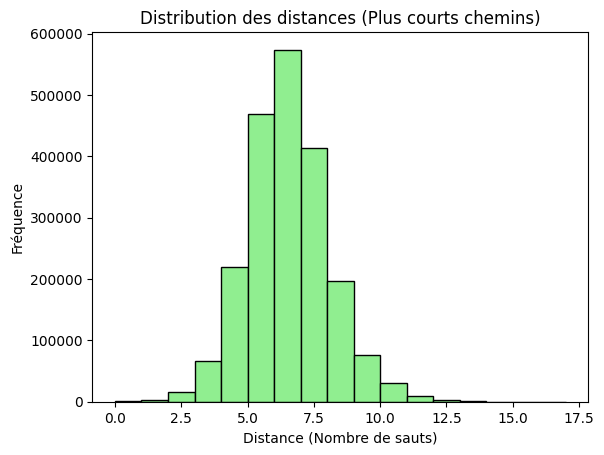

In [12]:
# On prend un échantillon car le calcul sur 4000x4000 est long
import random
sample_nodes = random.sample(list(G_main.nodes()), 500)
path_lengths = []
for n1 in sample_nodes:
    lengths = nx.single_source_shortest_path_length(G_main, n1)
    path_lengths.extend(lengths.values())

plt.hist(path_lengths, bins=range(int(max(path_lengths))+2), color='lightgreen', edgecolor='black')
plt.title("Distribution des distances (Plus courts chemins)")
plt.xlabel("Distance (Nombre de sauts)")
plt.ylabel("Fréquence")
plt.show()

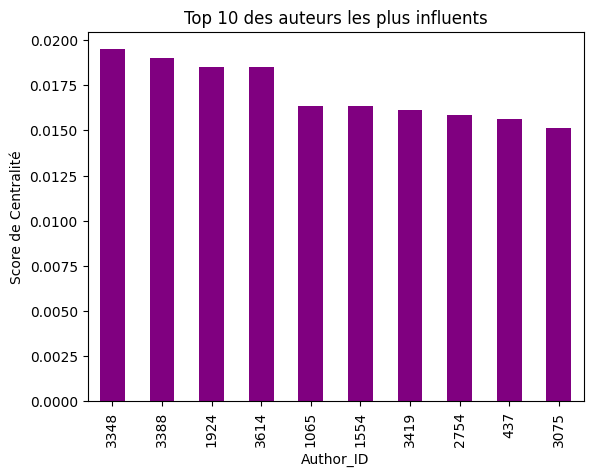

In [13]:
import pandas as pd

# On prend les 10 meilleurs
top_10 = sorted(deg_centrality.items(), key=lambda x: x[1], reverse=True)[:10]
df = pd.DataFrame(top_10, columns=['Author_ID', 'Centrality'])

df.plot(kind='bar', x='Author_ID', y='Centrality', color='purple', legend=False)
plt.title("Top 10 des auteurs les plus influents")
plt.ylabel("Score de Centralité")
plt.show()

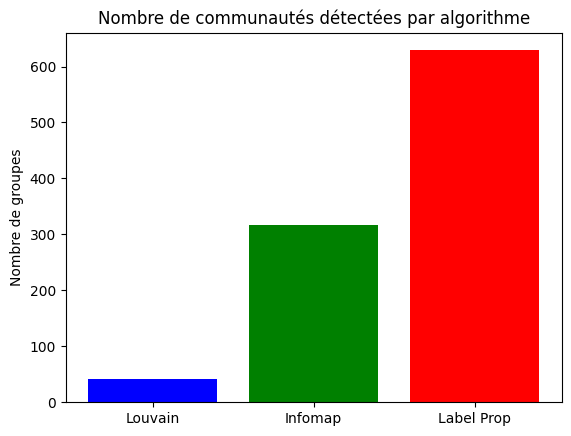

In [14]:
# Comparaison du nombre de communautés
algo_names = ['Louvain', 'Infomap', 'Label Prop']
counts = [len(coms_louvain.communities), len(coms_infomap.communities), len(coms_lp.communities)]

plt.bar(algo_names, counts, color=['blue', 'green', 'red'])
plt.title("Nombre de communautés détectées par algorithme")
plt.ylabel("Nombre de groupes")
plt.show()